In [1]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.preprocessing import LabelEncoder, OneHotEncoder, StandardScaler, PolynomialFeatures
from sklearn.model_selection import train_test_split
from sklearn.metrics import r2_score, mean_squared_error
from sklearn.linear_model import LinearRegression

In [2]:
data = pd.read_csv('Student_Performance.csv')

In [3]:
data.head()

,Hours Studied,Previous Scores,Extracurricular Activities,Sleep Hours,Sample Question Papers Practiced,Performance Index
0,7,99,Yes,9,1,91
1,4,82,No,4,2,65
2,8,51,Yes,7,2,45
3,5,52,Yes,5,2,36
4,7,75,No,8,5,66


In [5]:
data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 10000 entries, 0 to 9999
Data columns (total 6 columns):
 #   Column                            Non-Null Count  Dtype 
---  ------                            --------------  ----- 
 0   Hours Studied                     10000 non-null  int64 
 1   Previous Scores                   10000 non-null  int64 
 2   Extracurricular Activities        10000 non-null  object
 3   Sleep Hours                       10000 non-null  int64 
 4   Sample Question Papers Practiced  10000 non-null  int64 
 5   Performance Index                 10000 non-null  int64 
dtypes: int64(5), object(1)
memory usage: 468.9+ KB


In [6]:
data.describe()

,Hours Studied,Previous Scores,Sleep Hours,Sample Question Papers Practiced,Performance Index
count,10000.000000,10000.000000,10000.000000,10000.000000,10000.000000
mean,4.992900,69.445700,6.530600,4.583300,55.224800
std,2.589309,17.343152,1.695863,2.867348,19.212558
min,1.000000,40.000000,4.000000,0.000000,10.000000
25%,3.000000,54.000000,5.000000,2.000000,40.000000
50%,5.000000,69.000000,7.000000,5.000000,55.000000
75%,7.000000,85.000000,8.000000,7.000000,71.000000
max,9.000000,99.000000,9.000000,9.000000,100.000000


In [13]:
le = LabelEncoder()

In [14]:
data['Extracurricular Activities'] = le.fit_transform(data['Extracurricular Activities'])

<Axes: >

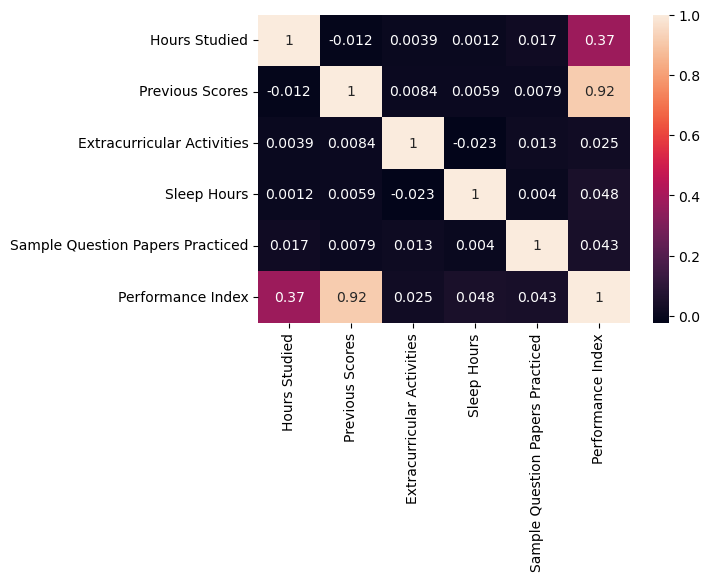

In [15]:
plt.figure(figsize=(6,4))
sns.heatmap(data.corr(), annot=True)

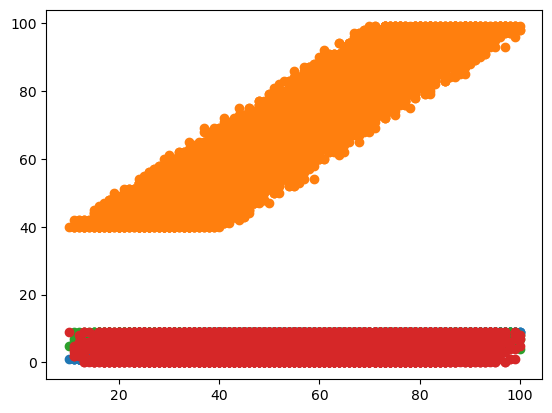

In [16]:
plt.scatter(x=data['Performance Index'], y=data['Hours Studied'])
plt.scatter(x=data['Performance Index'], y=data['Previous Scores'])
plt.scatter(x=data['Performance Index'], y=data['Sleep Hours'])
plt.scatter(x=data['Performance Index'], y=data['Sample Question Papers Practiced'])

In [17]:
X = data.drop(columns=['Performance Index'])
y= data[['Performance Index']]

In [18]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

In [19]:
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

In [20]:
model= LinearRegression()
model.fit(X_train_scaled, y_train)

LinearRegression()

In [21]:
y_pred = model.predict(X_test_scaled)

In [22]:
np.sqrt(mean_squared_error(y_pred, y_test))

np.float64(2.0205515085050014)

In [23]:
r2_score(y_pred, y_test)

0.9887203279837659